# Association Rule Learning
### Market Basket Analysis on the Groceries Dataset

**Assignment:** Association Rule Learning
**Dataset:** `groceries.csv` (one month of real shopping-basket data from a grocery store)

---

This notebook uses the Apriori algorithm to find out which products are commonly
bought together, then checks how strong each pattern is using support, confidence,
and lift (explained with real examples in Question 4).

## Step 0: Setting up

The `mlxtend` library already has the Apriori algorithm built in, so it doesn't
need to be written from scratch.

In [1]:
# Run once if mlxtend is not installed:
# !pip install mlxtend

In [2]:
import os
import csv
import warnings
from itertools import combinations
!pip install mlxtend
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

warnings.filterwarnings("ignore")

# Display / plotting conventions
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["font.size"] = 10

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

RANDOM_STATE = 42
print("Environment ready.")

Environment ready.


---
# Question 1: Understand the Data

## Loading the data

This CSV file is a bit different from a normal table. Each row is one shopping trip,
and the items bought in that trip are just listed one after another, separated by
commas. Some rows have more items than others, so the file has extra empty commas at
the end of shorter rows to pad them out.

Because of this, `pd.read_csv()` can't be used normally — it would create a messy
table full of empty columns. Instead, the file is read line by line and each line is
turned into a list of items (a "basket"). While doing this:

1. **Extra spaces are removed** — a few item names have a trailing space like `"cream cheese "`, which would otherwise be treated as a different item from `"cream cheese"`.
2. **Empty entries are skipped** — the padding commas.
3. **Duplicate items in the same basket are removed** — if the same item is listed twice, it should only be counted once.

In [3]:
# Portable path resolution: works whether the CSV sits next to the notebook,
# in a data/ subfolder, or in the uploads directory.
CANDIDATES = ["groceries.csv", "data/groceries.csv"]
CSV_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)
if CSV_PATH is None:
    raise FileNotFoundError(f"groceries.csv not found. Looked in: {CANDIDATES}")
print(f"Reading: {CSV_PATH}")

transactions = []
with open(CSV_PATH, newline="", encoding="utf-8") as fh:
    for row in csv.reader(fh):
        items = {field.strip() for field in row if field.strip()}   # strip + drop blanks + de-duplicate
        if items:                                                   # skip fully empty lines
            transactions.append(sorted(items))

print(f"Parsed {len(transactions):,} non-empty transactions.")
print("\nFirst 5 transactions:")
for i, t in enumerate(transactions[:5], start=1):
    print(f"  {i}. {t}")

Reading: groceries.csv
Parsed 9,835 non-empty transactions.

First 5 transactions:
  1. ['citrus fruit', 'margarine', 'ready soups', 'semi-finished bread']
  2. ['coffee', 'tropical fruit', 'yogurt']
  3. ['whole milk']
  4. ['cream cheese', 'meat spreads', 'pip fruit', 'yogurt']
  5. ['condensed milk', 'long life bakery product', 'other vegetables', 'whole milk']


## Q1 (a) and (b): How many transactions? How many different items?

In [4]:
n_transactions = len(transactions)
all_items = sorted({item for t in transactions for item in t})
n_items = len(all_items)

basket_sizes = pd.Series([len(t) for t in transactions], name="basket_size")

summary = pd.DataFrame({
    "Metric": [
        "Number of transactions",
        "Number of distinct grocery items",
        "Total items sold (item-transaction pairs)",
        "Mean basket size",
        "Median basket size",
        "Smallest basket",
        "Largest basket",
        "Density of the transaction matrix",
    ],
    "Value": [
        f"{n_transactions:,}",
        f"{n_items}",
        f"{basket_sizes.sum():,}",
        f"{basket_sizes.mean():.2f} items",
        f"{basket_sizes.median():.0f} items",
        f"{basket_sizes.min()} item",
        f"{basket_sizes.max()} items",
        f"{basket_sizes.sum() / (n_transactions * n_items):.4f}",
    ],
})
display(summary.style.hide(axis="index"))

Metric,Value
Number of transactions,"9,835"
Number of distinct grocery items,169
Total items sold (item-transaction pairs),"43,367"
Mean basket size,4.41 items
Median basket size,3 items
Smallest basket,1 item
Largest basket,32 items
Density of the transaction matrix,0.0261


### Answer to Q1 (a) and (b)

> **(a) There are 9,835 transactions.**
> **(b) There are 169 different items.**

The data is also very **sparse** — only about 2.6% of all the possible (basket,
item) combinations are actually filled in. On average, a basket only contains 4.41
items out of the 169 possible. This matters later, because it means a fairly low
support threshold (like 1%) is needed when looking for frequent itemsets — a higher
threshold (like 10%) would leave almost nothing.

## Q1 (c): What are the 10 most frequently purchased items?

In [5]:
# we are counting the number of times each item appears across all transactions, which gives us the frequency of each item.
item_counts = (
    pd.Series([item for t in transactions for item in t])
      .value_counts()
      .rename("frequency")
)
# we are calculating the support of each item by dividing its frequency by the total number of transactions.
item_support = (item_counts / n_transactions).rename("support")

top10 = (
    pd.concat([item_counts, item_support], axis=1)
      .head(10)
      .reset_index()
      .rename(columns={"index": "item"})
)
top10.columns = ["Item", "Frequency (count)", "Support (proportion)"]
top10.insert(0, "Rank", range(1, 11))
top10["Support (%)"] = (top10["Support (proportion)"] * 100).round(2)

print("Table 1 Top 10 most frequently purchased items")
display(top10.style.hide(axis="index").format({"Support (proportion)": "{:.4f}"}))

Table 1 Top 10 most frequently purchased items


Rank,Item,Frequency (count),Support (proportion),Support (%)
1,whole milk,2513,0.2555,25.550000
2,other vegetables,1903,0.1935,19.350000
3,rolls/buns,1809,0.1839,18.390000
4,soda,1715,0.1744,17.440000
5,yogurt,1372,0.1395,13.950000
6,bottled water,1087,0.1105,11.050000
7,root vegetables,1072,0.1090,10.900000
8,tropical fruit,1032,0.1049,10.490000
9,shopping bags,969,0.0985,9.850000
10,sausage,924,0.0940,9.400000


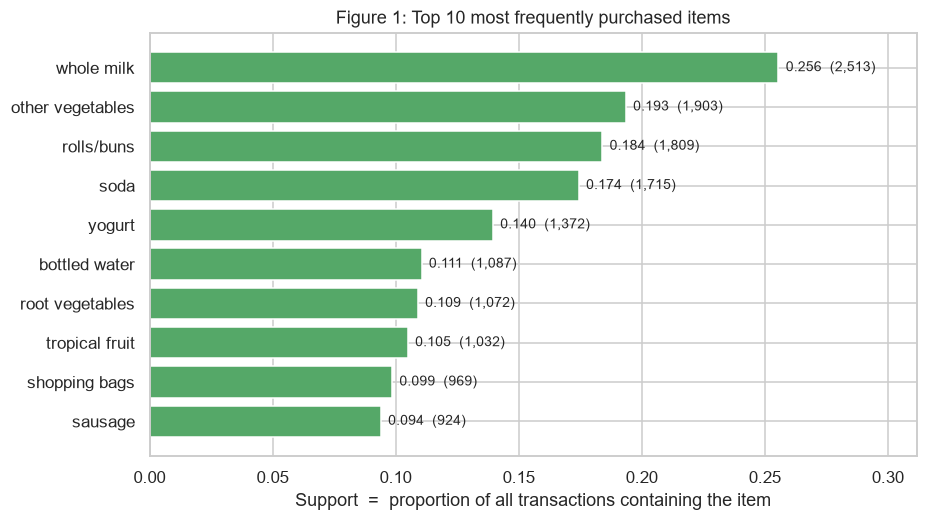

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = top10.iloc[::-1]
bars = ax.barh(plot_df["Item"], plot_df["Support (proportion)"], color="#55A868", edgecolor="white")
for bar, val, cnt in zip(bars, plot_df["Support (proportion)"], plot_df["Frequency (count)"]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}  ({cnt:,})", va="center", fontsize=9)
ax.set_xlim(0, top10["Support (proportion)"].max() * 1.22)
ax.set_xlabel("Support  =  proportion of all transactions containing the item")
ax.set_title("Figure 1: Top 10 most frequently purchased items")
plt.savefig(f"{FIG_DIR}/fig2_top10_items.png")
plt.show()

### Answer to Q1 (c)

**Top 10 items:**

| Rank | Item | Count | Support |
|---:|---|---:|---:|
| 1 | whole milk | 2,513 | 0.2555 |
| 2 | other vegetables | 1,903 | 0.1935 |
| 3 | rolls/buns | 1,809 | 0.1839 |
| 4 | soda | 1,715 | 0.1744 |
| 5 | yogurt | 1,372 | 0.1395 |
| 6 | bottled water | 1,087 | 0.1105 |
| 7 | root vegetables | 1,072 | 0.1090 |
| 8 | tropical fruit | 1,032 | 0.1049 |
| 9 | shopping bags | 969 | 0.0985 |
| 10 | sausage | 924 | 0.0940 |

Whole milk is bought in about 1 out of every 4 baskets, and nothing else even reaches
20%. This looks like a "quick top-up shop" pattern rather than a big weekly grocery
run — mostly everyday staples like milk, bread, and vegetables.

One thing to keep in mind for later: because whole milk is bought so often on its
own, almost *any* rule that ends in "→ whole milk" will look like it has decent
confidence, just because milk is everywhere. That's not a real pattern by itself —
this comes up again in Question 8.

---
# Question 2: Frequent Itemsets

## Turning the baskets into a table

To run Apriori, the data needs to be in a different shape: one row per transaction,
one column per item, and `True`/`False` for whether that item was bought. The
`TransactionEncoder` tool handles this conversion.

In [7]:
encoder = TransactionEncoder()
basket_matrix = pd.DataFrame(
    encoder.fit(transactions).transform(transactions),
    columns=encoder.columns_,
)

print(f"One-hot matrix shape: {basket_matrix.shape[0]:,} transactions x {basket_matrix.shape[1]} items")
display(basket_matrix.iloc[:5, :8])

One-hot matrix shape: 9,835 transactions x 169 items


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False


## Choosing the minimum support

A minimum support value needs to be chosen — this decides how "common" something
has to be before it counts as a frequent itemset.

- `min_support = 0.01` means an itemset needs to show up in at least 1% of baskets (about 99 transactions) to count.
- Setting this too high (like 0.05) leaves almost nothing except the most popular items.
- Setting it too low (like 0.001) produces thousands of itemsets, many of which are just noise from a handful of baskets.

Since the average basket only has 4.41 items (pretty sparse, as found in Question 1),
**1% support** was chosen as a reasonable middle ground, and is used for the rest of
the notebook.

In [8]:
MIN_SUPPORT = 0.01

frequent_itemsets = apriori(basket_matrix, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)
frequent_itemsets["items"] = frequent_itemsets["itemsets"].apply(lambda s: ", ".join(sorted(s)))
frequent_itemsets = frequent_itemsets.sort_values("support", ascending=False).reset_index(drop=True)

print(f"min_support = {MIN_SUPPORT}  ->  {len(frequent_itemsets)} frequent itemsets in total")
print(frequent_itemsets["length"].value_counts().sort_index().rename("count").to_frame().T)

min_support = 0.01  ->  333 frequent itemsets in total
length   1    2   3
count   88  213  32


## Q2 (a) and (b): Find at least 10 frequent itemsets (2+ items) and their support values

In [9]:
multi_itemsets = (
    frequent_itemsets[frequent_itemsets["length"] >= 2]
    .sort_values("support", ascending=False)
    .reset_index(drop=True)
)

print(f"{len(multi_itemsets)} frequent itemsets contain 2 or more products "
      f"({(multi_itemsets['length'] == 2).sum()} pairs, {(multi_itemsets['length'] == 3).sum()} triples).")

top_itemsets = multi_itemsets.head(15).copy()
top_itemsets["Rank"] = range(1, len(top_itemsets) + 1)
top_itemsets["Transactions"] = (top_itemsets["support"] * n_transactions).round().astype(int)
top_itemsets["Support (%)"] = (top_itemsets["support"] * 100).round(2)

print("\nTable 2: Top 15 frequent itemsets of size >= 2 (min_support = 1%)")
display(
    top_itemsets[["Rank", "items", "length", "support", "Support (%)", "Transactions"]]
    .rename(columns={"items": "Itemset", "length": "Size", "support": "Support"})
    .style.hide(axis="index").format({"Support": "{:.4f}"})
)

245 frequent itemsets contain 2 or more products (213 pairs, 32 triples).

Table 2: Top 15 frequent itemsets of size >= 2 (min_support = 1%)


Rank,Itemset,Size,Support,Support (%),Transactions
1,"other vegetables, whole milk",2,0.0748,7.480000,736
2,"rolls/buns, whole milk",2,0.0566,5.660000,557
3,"whole milk, yogurt",2,0.0560,5.600000,551
4,"root vegetables, whole milk",2,0.0489,4.890000,481
5,"other vegetables, root vegetables",2,0.0474,4.740000,466
6,"other vegetables, yogurt",2,0.0434,4.340000,427
7,"other vegetables, rolls/buns",2,0.0426,4.260000,419
8,"tropical fruit, whole milk",2,0.0423,4.230000,416
9,"soda, whole milk",2,0.0401,4.010000,394
10,"rolls/buns, soda",2,0.0383,3.830000,377


In [10]:
# The largest itemsets found at this threshold
triples = multi_itemsets[multi_itemsets["length"] == 3].sort_values("support", ascending=False)
print(f"Table 3: All {len(triples)} frequent 3-itemsets at min_support = 1%")
display(
    triples[["items", "support"]]
    .assign(**{"Transactions": (triples["support"] * n_transactions).round().astype(int)})
    .rename(columns={"items": "Itemset", "support": "Support"})
    .reset_index(drop=True)
    .style.hide(axis="index").format({"Support": "{:.4f}"})
)

Table 3: All 32 frequent 3-itemsets at min_support = 1%


Itemset,Support,Transactions
"other vegetables, root vegetables, whole milk",0.0232,228
"other vegetables, whole milk, yogurt",0.0223,219
"other vegetables, rolls/buns, whole milk",0.0179,176
"other vegetables, tropical fruit, whole milk",0.0171,168
"rolls/buns, whole milk, yogurt",0.0156,153
"tropical fruit, whole milk, yogurt",0.0151,149
"other vegetables, whipped/sour cream, whole milk",0.0146,144
"root vegetables, whole milk, yogurt",0.0145,143
"other vegetables, soda, whole milk",0.0139,137
"other vegetables, pip fruit, whole milk",0.0135,133


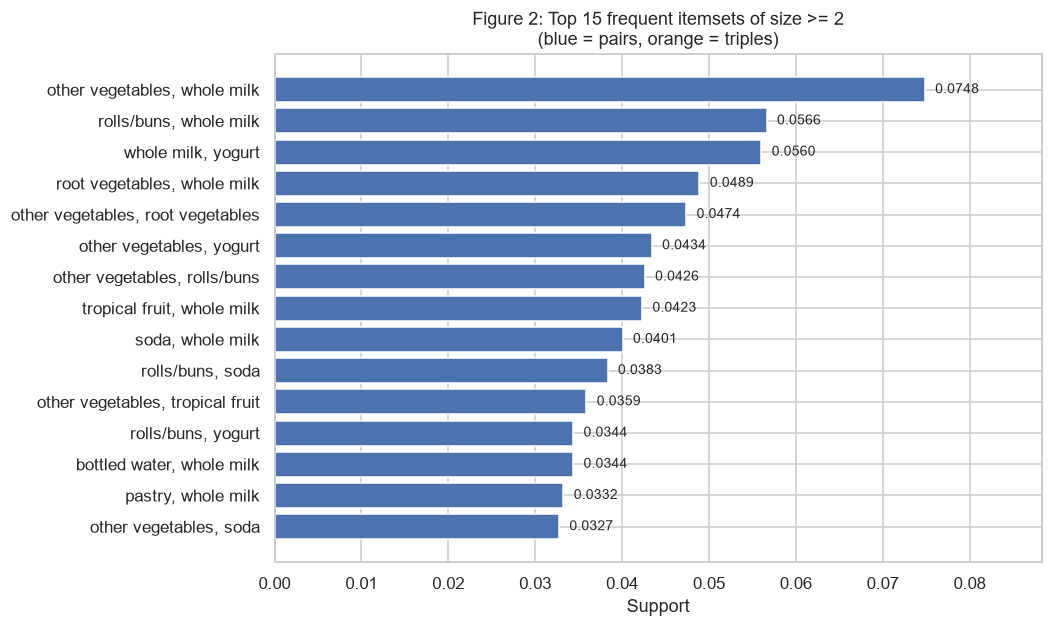

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
pl = top_itemsets.iloc[::-1]
colors = ["#4C72B0" if s == 2 else "#DD8452" for s in pl["length"]]
bars = ax.barh(pl["items"], pl["support"], color=colors, edgecolor="white")
for bar, val in zip(bars, pl["support"]):
    ax.text(val + 0.0012, bar.get_y() + bar.get_height() / 2, f"{val:.4f}", va="center", fontsize=9)
ax.set_xlim(0, top_itemsets["support"].max() * 1.18)
ax.set_xlabel("Support")
ax.set_title("Figure 2: Top 15 frequent itemsets of size >= 2\n(blue = pairs, orange = triples)")
plt.savefig(f"{FIG_DIR}/fig3_frequent_itemsets.png")
plt.show()

### Answer to Q2 (a) and (b)

Using 1% minimum support, Apriori found **245 frequent itemsets with 2 or more items**
(213 pairs and 32 triples) — more than the 10 required. Here are the top 10 by support:

| # | Itemset | Support | Transactions |
|---:|---|---:|---:|
| 1 | {whole milk, other vegetables} | 0.0748 | 736 |
| 2 | {whole milk, rolls/buns} | 0.0566 | 557 |
| 3 | {whole milk, yogurt} | 0.0560 | 551 |
| 4 | {whole milk, root vegetables} | 0.0489 | 481 |
| 5 | {other vegetables, root vegetables} | 0.0474 | 466 |
| 6 | {other vegetables, yogurt} | 0.0434 | 427 |
| 7 | {other vegetables, rolls/buns} | 0.0426 | 419 |
| 8 | {whole milk, tropical fruit} | 0.0423 | 416 |
| 9 | {whole milk, soda} | 0.0401 | 394 |
| 10 | {rolls/buns, soda} | 0.0383 | 377 |

The biggest itemsets found had 3 items (like {whole milk, other vegetables, root
vegetables}). Nothing with 4 items reached the 1% support level — likely because
baskets are so small on average.

### Q2 (c): Which itemset has the highest support?

> **`{whole milk, other vegetables}`**, with support **0.0748** (about 7.5%, or 736 out of 9,835 baskets).

### Q2 (d): What does the support value tell us about customer behavior?

Support simply shows **how common** a pattern is — the percentage of all baskets
that contain that combination.

A few observations:

1. **Even the top pattern is still a small minority.** Only 7.5% of shoppers bought milk and vegetables together — meaning about 92.5% of customers did *not*. So "customers often buy X and Y together" doesn't mean "most customers."
2. **Support is mostly driven by how popular each item already is**, not by whether they're actually connected. Every item in the top 10 itemsets is also in the top 10 single items. Two things can look "linked" just because both are popular on their own — this is exactly why confidence and lift are also needed, not just support (see Question 3).
3. **The pattern looks like everyday staples** — milk, vegetables, bread — the kind of stuff people buy on a normal grocery run, not a special occasion.
4. **Support also indicates the size of a business opportunity.** A 1% itemset is only about 99 baskets a month — maybe too small to act on. A 7.5% itemset (736 baskets) is a lot more meaningful in terms of actual sales.

---
# Question 3: Association Rules

## Generating the rules

Every frequent itemset with 2+ items can be split into a rule in different ways
(e.g., {A, B} can become "A → B" or "B → A"). Apriori/mlxtend does this automatically
and keeps only the rules whose confidence is above a chosen threshold.

**min_confidence = 0.25** was used here, meaning a rule is only kept if the "then"
part actually happens at least 25% of the time when the "if" part is true. Below
that, a rule would be too unreliable to be useful.

A small helper function also turns the messy `frozenset` output from mlxtend into
plain, readable text like `{milk, bread}`.

In [12]:
MIN_CONFIDENCE = 0.25

rules = association_rules(
    frequent_itemsets[["support", "itemsets"]],
    metric="confidence",
    min_threshold=MIN_CONFIDENCE,
)

def fs_to_str(fs):
    return "{" + ", ".join(sorted(fs)) + "}"

rules["antecedent"]   = rules["antecedents"].apply(fs_to_str)
rules["consequent"]   = rules["consequents"].apply(fs_to_str)
rules["rule"]         = rules["antecedent"] + "  ->  " + rules["consequent"]
rules["ant_len"]      = rules["antecedents"].apply(len)
rules["transactions"] = (rules["support"] * n_transactions).round().astype(int)

rules = rules.sort_values("lift", ascending=False).reset_index(drop=True)

print(f"min_support = {MIN_SUPPORT}, min_confidence = {MIN_CONFIDENCE}  ->  {len(rules)} association rules")
print(f"  rules with a single-item antecedent : {(rules['ant_len'] == 1).sum()}")
print(f"  rules with a two-item antecedent    : {(rules['ant_len'] == 2).sum()}")
print(f"  rules with lift > 1                 : {(rules['lift'] > 1).sum()}")
print(f"  rules with lift < 1                 : {(rules['lift'] < 1).sum()}")

min_support = 0.01, min_confidence = 0.25  ->  170 association rules
  rules with a single-item antecedent : 96
  rules with a two-item antecedent    : 74
  rules with lift > 1                 : 169
  rules with lift < 1                 : 1


## Q3 (a) and (b): At least 10 rules with antecedent, consequent, support, confidence, lift

Below is a table of the top 15 rules, sorted by lift, since lift shows which rules
are the most genuinely connected, not just the most popular.

In [13]:
RULE_COLS = ["antecedent", "consequent", "support", "confidence", "lift", "transactions"]

top_rules = rules.head(15).copy()
top_rules.insert(0, "Rule #", range(1, len(top_rules) + 1))

print("Table 4: Top 15 association rules ranked by lift "
      f"(min_support = {MIN_SUPPORT}, min_confidence = {MIN_CONFIDENCE})")
display(
    top_rules[["Rule #"] + RULE_COLS]
    .rename(columns={"antecedent": "Antecedent (X)", "consequent": "Consequent (Y)",
                     "support": "Support", "confidence": "Confidence", "lift": "Lift",
                     "leverage": "Leverage", "conviction": "Conviction",
                     "transactions": "N baskets"})
    .style.hide(axis="index")
    .format({"Support": "{:.4f}", "Confidence": "{:.4f}", "Lift": "{:.4f}",
             "Leverage": "{:.5f}", "Conviction": "{:.3f}"})
    .background_gradient(subset=["Lift"], cmap="YlOrRd")
)

Table 4: Top 15 association rules ranked by lift (min_support = 0.01, min_confidence = 0.25)


Rule #,Antecedent (X),Consequent (Y),Support,Confidence,Lift,N baskets
1,"{citrus fruit, other vegetables}",{root vegetables},0.0104,0.3592,3.2950,102
2,"{other vegetables, tropical fruit}",{root vegetables},0.0123,0.3428,3.1448,121
3,{beef},{root vegetables},0.0174,0.3314,3.0404,171
4,"{citrus fruit, root vegetables}",{other vegetables},0.0104,0.5862,3.0296,102
5,"{root vegetables, tropical fruit}",{other vegetables},0.0123,0.5845,3.0210,121
6,"{other vegetables, whole milk}",{root vegetables},0.0232,0.3098,2.8421,228
7,"{curd, whole milk}",{yogurt},0.0101,0.3852,2.7614,99
8,"{other vegetables, yogurt}",{root vegetables},0.0129,0.2974,2.7287,127
9,"{other vegetables, yogurt}",{tropical fruit},0.0123,0.2834,2.7005,121
10,"{other vegetables, rolls/buns}",{root vegetables},0.0122,0.2864,2.6275,120


### Answer to Q3 (a) and (b)

In total, **170 association rules** were generated using 1% support and 25%
confidence. Here are 10 of the strongest ones (by lift):

| # | Antecedent | Consequent | Support | Confidence | Lift |
|---:|---|---|---:|---:|---:|
| 1 | {citrus fruit, other vegetables} | {root vegetables} | 0.0104 | 0.359 | 3.295 |
| 2 | {tropical fruit, other vegetables} | {root vegetables} | 0.0123 | 0.343 | 3.145 |
| 3 | {beef} | {root vegetables} | 0.0174 | 0.331 | 3.040 |
| 4 | {citrus fruit, root vegetables} | {other vegetables} | 0.0104 | 0.586 | 3.030 |
| 5 | {tropical fruit, root vegetables} | {other vegetables} | 0.0123 | 0.585 | 3.021 |
| 6 | {whole milk, other vegetables} | {root vegetables} | 0.0232 | 0.310 | 2.842 |
| 7 | {curd, whole milk} | {yogurt} | 0.0101 | 0.385 | 2.761 |
| 8 | {other vegetables, yogurt} | {root vegetables} | 0.0129 | 0.297 | 2.729 |
| 9 | {other vegetables, yogurt} | {tropical fruit} | 0.0123 | 0.283 | 2.701 |
| 10 | {other vegetables, rolls/buns} | {root vegetables} | 0.0122 | 0.286 | 2.628 |

Two things stand out:

- **Fresh produce items keep showing up together at the top** — citrus fruit, tropical fruit, root vegetables, other vegetables. This makes sense: people likely buy these together when cooking a meal.
- **`{beef} → {root vegetables}`** is notable because it's the strongest rule that only needs *one* item as the antecedent — consistent with something like a stew or roast dinner.

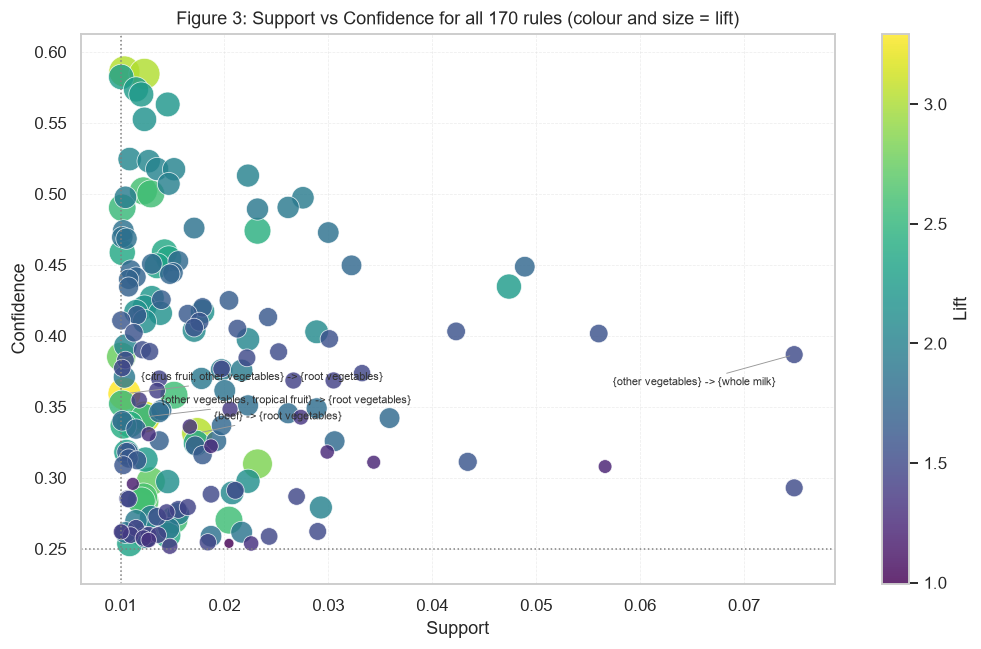

In [14]:
# Figure 3: the classic support / confidence / lift scatter
fig, ax = plt.subplots(figsize=(9.5, 6))

# normalized marker size (so lift actually reads visually)
lift = rules["lift"].to_numpy()
sizes = 42 + 420 * (lift - lift.min()) / (lift.max() - lift.min() + 1e-9)

sc = ax.scatter(rules["support"], rules["confidence"],
                c=rules["lift"], s=sizes,
                cmap="viridis", alpha=0.82, edgecolors="white", linewidths=0.5)
cbar = plt.colorbar(sc, ax=ax); cbar.set_label("Lift")

# pad limits so the threshold lines are actually visible
x_range = rules["support"].max() - rules["support"].min() + 1e-9
y_range = rules["confidence"].max() - rules["confidence"].min() + 1e-9

ax.axhline(MIN_CONFIDENCE, color="grey", ls=":", lw=1, zorder=1)
ax.axvline(MIN_SUPPORT,    color="grey", ls=":", lw=1, zorder=1)

for _, r in rules.nlargest(3, "lift").iterrows():
    ax.annotate(r["rule"].replace("  ->  ", " -> "),
                (r["support"], r["confidence"]),
                textcoords="offset points", xytext=(11, 9),
                fontsize=7.5, color="#333333",
                arrowprops=dict(arrowstyle="-", color="#999", lw=0.6,
                                shrinkA=0, shrinkB=3))
for _, r in rules.nlargest(1, "support").iterrows():
    ax.annotate(r["rule"].replace("  ->  ", " -> "),
                (r["support"], r["confidence"]),
                textcoords="offset points", xytext=(-12, -20),
                fontsize=7.5, ha="right", color="#333333",
                arrowprops=dict(arrowstyle="-", color="#999", lw=0.6,
                                shrinkA=0, shrinkB=3))

ax.set_xlim(rules["support"].min()    - 0.06 * x_range,
            rules["support"].max()    + 0.06 * x_range)
ax.set_ylim(rules["confidence"].min() - 0.08 * y_range,
            rules["confidence"].max() + 0.08 * y_range)
ax.set_xlabel("Support"); ax.set_ylabel("Confidence")
ax.set_title(f"Figure 3: Support vs Confidence for all {len(rules)} rules (colour and size = lift)")
ax.grid(True, ls="--", lw=0.5, alpha=0.35)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig4_support_confidence_lift.png", dpi=150, bbox_inches="tight")
plt.show()

---
# Question 4: Understanding the Measures

Three different rules are examined below, chosen to compare a high-lift rule, a
high-confidence rule, and a high-support rule side by side.

In [15]:
SELECTED = [
    ("{citrus fruit, other vegetables}", "{root vegetables}"),
    ("{curd, whole milk}",               "{yogurt}"),
    ("{other vegetables}",               "{whole milk}"),
]

sel = pd.concat(
    [rules[(rules["antecedent"] == a) & (rules["consequent"] == c)] for a, c in SELECTED]
).reset_index(drop=True)
sel.insert(0, "Rule", ["R1", "R2", "R3"])

print("Table 5: The three rules chosen for detailed interpretation")
display(
    sel[["Rule", "antecedent", "consequent", "antecedent support", "consequent support",
         "support", "confidence", "lift", "transactions"]]
    .rename(columns={"antecedent": "X", "consequent": "Y",
                     "antecedent support": "supp(X)", "consequent support": "supp(Y)",
                     "support": "supp(X&Y)", "confidence": "conf", "lift": "lift",
                     "transactions": "N baskets"})
    .style.hide(axis="index")
    .format({"supp(X)": "{:.4f}", "supp(Y)": "{:.4f}", "supp(X&Y)": "{:.4f}",
             "conf": "{:.4f}", "lift": "{:.4f}"})
)

Table 5: The three rules chosen for detailed interpretation


Rule,X,Y,supp(X),supp(Y),supp(X&Y),conf,lift,N baskets
R1,"{citrus fruit, other vegetables}",{root vegetables},0.0289,0.1090,0.0104,0.3592,3.2950,102
R2,"{curd, whole milk}",{yogurt},0.0261,0.1395,0.0101,0.3852,2.7614,99
R3,{other vegetables},{whole milk},0.1935,0.2555,0.0748,0.3868,1.5136,736


### Answer to Q4

---

#### Rule 1: `{citrus fruit, other vegetables} → {root vegetables}`
*support = 0.0104, confidence = 0.359, lift = 3.295*

**(a) Support.** All three items (citrus fruit, other vegetables, root vegetables)
appear together in about **1.04% of all baskets** (102 out of 9,835) — a pretty
small slice of all shopping trips.

**(b) Confidence.** Of the people who bought citrus fruit and other vegetables,
**35.9% also bought root vegetables**. This only goes one direction — it doesn't
show how often root-vegetable buyers also buy citrus fruit.

**(c) Lift.** Root vegetables show up in 10.9% of all baskets normally. But for this
specific group of shoppers, it jumps to 35.9% — about **3.3 times higher** than
normal. That's a strong sign these items are genuinely linked, not just a
coincidence.

---

#### Rule 2: `{curd, whole milk} → {yogurt}`
*support = 0.0101, confidence = 0.385, lift = 2.761*

**(a) Support.** This combination shows up in just **1.01%** of baskets (99 of
9,835) — barely enough to even count as "frequent" at the chosen threshold.

**(b) Confidence.** **38.5%** of people who bought curd and whole milk also bought
yogurt — actually the highest confidence of the three rules picked here, even
though it has the lowest support. Support and confidence really are two separate
things.

**(c) Lift.** Yogurt normally shows up in 13.95% of baskets. For curd + milk buyers,
it's 38.5% — **2.76 times higher**. This makes sense: someone buying two dairy
products is likely also buying a third one (a "dairy run").

---

#### Rule 3: `{other vegetables} → {whole milk}`
*support = 0.0748, confidence = 0.387, lift = 1.514*

**(a) Support.** This pair shows up in **7.48%** of all baskets (736 of 9,835) — the
highest support out of any rule found, by far.

**(b) Confidence.** **38.7%** of vegetable buyers also bought whole milk — sounds
decent on its own.

**(c) Lift.** But whole milk is already in 25.6% of *all* baskets, so 38.7% is only
**1.51 times** higher than normal. That's a much weaker signal than Rules 1 and 2 —
most of that "confidence" is just because milk is so popular in general, not because
vegetables and milk have some special connection.

---

**Comparing the three:** Rule 3 has 7 times the support of Rule 1, but less than
half the lift. Rule 2 has the highest confidence but the lowest support. This shows
that support, confidence, and lift really do measure different things — how common
(support), how reliable (confidence), and how much better than random chance
(lift) — and all three need to be considered together, not just one.

---
# Question 5: Find Interesting Rules

In [16]:
best = {
    "Highest CONFIDENCE": rules.loc[rules["confidence"].idxmax()],
    "Highest LIFT":       rules.loc[rules["lift"].idxmax()],
    "Highest SUPPORT":    rules.loc[rules["support"].idxmax()],
}

extremes = pd.DataFrame([
    {"Criterion": k, "Antecedent": v["antecedent"], "Consequent": v["consequent"],
     "Support": v["support"], "Confidence": v["confidence"], "Lift": v["lift"],
     "N baskets": v["transactions"]}
    for k, v in best.items()
])

print("Table 6: The extreme rules under each criterion")
display(extremes.style.hide(axis="index")
        .format({"Support": "{:.4f}", "Confidence": "{:.4f}", "Lift": "{:.4f}"}))

print("\nAre they the same rule?")
ids = {k: (v["antecedent"], v["consequent"]) for k, v in best.items()}
for k, v in ids.items():
    print(f"  {k:<20}: {v[0]} -> {v[1]}")
print(f"\n  All three identical? {len(set(ids.values())) == 1}"
      f"   ({len(set(ids.values()))} distinct rules)")

Table 6: The extreme rules under each criterion


Criterion,Antecedent,Consequent,Support,Confidence,Lift,N baskets
Highest CONFIDENCE,"{citrus fruit, root vegetables}",{other vegetables},0.0104,0.5862,3.0296,102
Highest LIFT,"{citrus fruit, other vegetables}",{root vegetables},0.0104,0.3592,3.2950,102
Highest SUPPORT,{other vegetables},{whole milk},0.0748,0.3868,1.5136,736



Are they the same rule?
  Highest CONFIDENCE  : {citrus fruit, root vegetables} -> {other vegetables}
  Highest LIFT        : {citrus fruit, other vegetables} -> {root vegetables}
  Highest SUPPORT     : {other vegetables} -> {whole milk}

  All three identical? False   (3 distinct rules)


### Answer to Q5

**(a) Highest confidence**

> **`{citrus fruit, root vegetables} → {other vegetables}`** — confidence **0.586**
> (support 0.0104, lift 3.030)

Almost 59% of people who bought citrus fruit and root vegetables also bought other
vegetables — the most "reliable" rule found.

**(b) Highest lift**

> **`{citrus fruit, other vegetables} → {root vegetables}`** — lift **3.295**
> (support 0.0104, confidence 0.359)

This is the strongest *real* connection — buying these two more than triples the
chance of buying root vegetables too.

**(c) Highest support**

> **`{other vegetables} → {whole milk}`** — support **0.0748**
> (confidence 0.387, lift 1.514)

(Note: the reverse rule, `{whole milk} → {other vegetables}`, has the exact same
support — support doesn't care about direction, only confidence and lift do.)

**(d) Are these the same rule?**

**No — all three are different rules,** and two of them don't even share the same
items.

Here's why: each measure rewards something different.

| Measure | What it rewards |
|---|---|
| Support | Popular items in general (both items need to already be common) |
| Confidence | A rule where the "then" item is common, or the "if" part is very specific |
| Lift | A pattern that's genuinely stronger than random chance — not just popular items |

Support and lift actually tend to pull in **opposite directions**. To get high
support, both items need to be popular already — but popular items have high lift
denominators, so lift goes *down*. That's exactly what shows up here: the
highest-support rule has the *lowest* lift (1.51) of the bunch, while the
highest-lift rule has support that's about 7 times smaller.

**Overall takeaway:** there's no single "best" rule. Support indicates how big the
opportunity is, confidence shows how reliable a recommendation would be, and lift
checks whether the pattern is actually real and not just because both items are
popular.

---
# Question 6: Interpret a Rule

A rule is selected below in the form the assignment asked for, `{Product A, Product B} → {Product C}`:

> ### `{tropical fruit, root vegetables} → {other vegetables}`

In [17]:
chosen = rules[(rules["antecedent"] == "{root vegetables, tropical fruit}") &
               (rules["consequent"] == "{other vegetables}")].iloc[0]

X, Y = set(chosen["antecedents"]), set(chosen["consequents"])
n_X  = sum(1 for t in transactions if X <= set(t))
n_XY = sum(1 for t in transactions if (X | Y) <= set(t))
n_Y  = sum(1 for t in transactions if Y <= set(t))

print(f"RULE:  {chosen['antecedent']}  ->  {chosen['consequent']}")
print("=" * 74)
print(f"  Baskets containing tropical fruit AND root vegetables : {n_X:>5}")
print(f"  ... of which also contain other vegetables            : {n_XY:>5}")
print(f"  Baskets containing other vegetables (anywhere)        : {n_Y:>5}")
print("-" * 74)
print(f"  Support     = {chosen['support']:.4f}   ({n_XY} of {n_transactions} baskets, "
      f"{chosen['support']*100:.2f}%)")
print(f"  Confidence  = {chosen['confidence']:.4f}   ({n_XY}/{n_X} = "
      f"{chosen['confidence']*100:.1f}% of antecedent baskets)")
print(f"  Base rate   = {n_Y/n_transactions:.4f}   (other vegetables in "
      f"{n_Y/n_transactions*100:.1f}% of all baskets)")
print(f"  Lift        = {chosen['lift']:.4f}   ({chosen['confidence']*100:.1f}% / "
      f"{n_Y/n_transactions*100:.1f}% = {chosen['lift']:.2f}x the base rate)")
print(f"  Leverage    = {chosen['leverage']:.5f}")
print(f"  Conviction  = {chosen['conviction']:.3f}")

RULE:  {root vegetables, tropical fruit}  ->  {other vegetables}
  Baskets containing tropical fruit AND root vegetables :   207
  ... of which also contain other vegetables            :   121
  Baskets containing other vegetables (anywhere)        :  1903
--------------------------------------------------------------------------
  Support     = 0.0123   (121 of 9835 baskets, 1.23%)
  Confidence  = 0.5845   (121/207 = 58.5% of antecedent baskets)
  Base rate   = 0.1935   (other vegetables in 19.3% of all baskets)
  Lift        = 3.0210   (58.5% / 19.3% = 3.02x the base rate)
  Leverage    = 0.00823
  Conviction  = 1.941


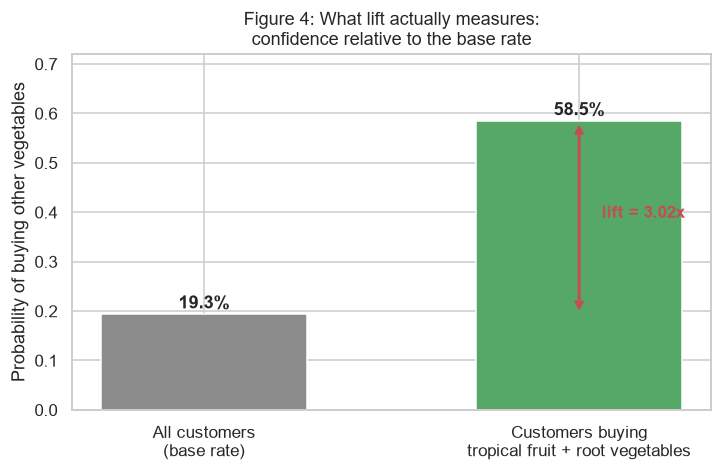

In [18]:
# Figure 4: confidence against the base rate, which is what lift measures
fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.bar(["All customers\n(base rate)", "Customers buying\ntropical fruit + root vegetables"],
              [n_Y / n_transactions, chosen["confidence"]],
              color=["#8C8C8C", "#55A868"], edgecolor="white", width=0.55)
for b, v in zip(bars, [n_Y / n_transactions, chosen["confidence"]]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.012, f"{v:.1%}",
            ha="center", fontsize=12, fontweight="bold")
ax.annotate("", xy=(1, chosen["confidence"]), xytext=(1, n_Y / n_transactions),
            arrowprops=dict(arrowstyle="<->", color="#C44E52", lw=2))
ax.text(1.06, (chosen["confidence"] + n_Y / n_transactions) / 2,
        f"lift = {chosen['lift']:.2f}x", color="#C44E52", fontsize=11, fontweight="bold")
ax.set_ylabel("Probability of buying other vegetables")
ax.set_ylim(0, 0.72)
ax.set_title("Figure 4: What lift actually measures:\nconfidence relative to the base rate")
plt.savefig(f"{FIG_DIR}/fig8_rule_interpretation.png")
plt.show()

### Answer to Q6

#### In plain English

> **Customers who buy tropical fruit and root vegetables also tend to buy other vegetables.**

With the actual numbers:

- **Support (0.0123):** about 12 out of every 1,000 shopping trips have all three items — 121 out of 9,835 baskets in total.
- **Confidence (0.585):** out of the 207 people who bought tropical fruit and root vegetables together, 121 of them (about 59%) also bought other vegetables — almost a coin flip in favor of "yes, they bought vegetables too."
- **Lift (3.021):** normally, other vegetables show up in 19.4% of baskets. For this group of shoppers it jumps to 58.5% — about **3 times** the normal rate.

#### Is this strong or weak?

**This is a strong association**, for a few reasons:

1. Lift of 3.02 is well above 1 — meaning this is much more common than random chance would predict.
2. Confidence of 58.5% is genuinely useful — predicting "this shopper will also buy vegetables" would be right more often than wrong.
3. It's a small slice of all baskets though — only 1.23% support. So this is a **strong but narrow** pattern: it describes a small group of shoppers really well (likely people cooking a meal), but it doesn't touch most of the store's customers.

---
# Question 7: Business Application

The rules above are used below to make some concrete decisions, from the
perspective of a supermarket manager.

### Answer to Q7

#### (a) Two products to place near each other

> **Root vegetables and other vegetables.**

These two have a lift of 2.246 and a support of 4.74% (466 baskets) — a good mix of
"these are genuinely linked" and "enough people buy both to make it worth it."
Confidence is decent in both directions too (43.5% one way, 24.5% the other), so it
should work no matter which item brings the customer to that aisle first.

Another option is **beef and root vegetables** (lift 3.04) — placing a root
vegetable display near the meat counter could work well for people planning a stew
or roast.

**One thing to avoid:** placing whole milk next to things just because it shows up
in a lot of co-occurring pairs isn't a good idea — that's mostly because milk is
popular on its own, not because of a real connection (lift close to 1). This is
actually why stores usually put milk *far* from the entrance — to make people walk
past other sections first.

#### (b) One product bundle idea

> **"Fresh Meal Basket": whole milk + other vegetables + root vegetables**

This 3-item combo has the highest support of any triple found (0.0232, 228
baskets), and the rule `{whole milk, other vegetables} → {root vegetables}` has a
decent lift of 2.842. The idea is to use two very popular items (milk, vegetables)
to help sell more of a less popular one (root vegetables, only in 10.9% of baskets
normally).

#### (c) Example of using rules for recommendations

> **Recommending items at checkout or in an app cart.**

If a customer's cart already has tropical fruit and root vegetables, the rule
`{tropical fruit, root vegetables} → {other vegetables}` (confidence 58.5%, lift
3.02) could trigger a message like *"Customers who bought these also bought other
vegetables."*

This works better than a random promotion because:
1. It's targeted — it only shows up for the right group of shoppers.
2. The confidence (58.5%) means it'll actually be right more often than not.
3. The lift (3.02) means it's not just recommending something popular anyway — it's an actual pattern.

---
# Question 8: Understanding Association

## Testing a couple of ideas on the real data

Before answering these questions, a couple of quick checks were run on the actual
data to back up the answers below.

### Answer to Q8

#### (a) Does an association rule prove that buying one product causes someone to buy another?

> **No. Association rules only show a connection (correlation), not a cause.**

The algorithm just counts how often items appear together — it has no concept of
*why*. A few reasons this matters:

1. The support/confidence/lift numbers are only built from counting how often items appear together — nothing about *why* someone bought them.
2. Lift is symmetric — lift(X → Y) is exactly the same as lift(Y → X). If a measure can't even tell which item "came first," it definitely can't prove which one caused the other.
3. It's very possible both items are caused by something else entirely — like a recipe, a holiday, or general shopping habits — rather than one item causing someone to buy the other.
4. To actually prove causation, an experiment would be needed (like an A/B test where the store shows a promotion to one group but not another), not just historical data.

**Why this matters for a business:** if a manager assumes "buying X causes people to
buy Y" and discounts X to boost Y, but the real reason both were bought was some
other factor (like a specific meal), the store just loses money on the discount
without actually selling more of Y.

#### (b) Why might a rule have high confidence but low lift?

> **Because confidence doesn't account for how popular the "then" item already is — but lift does.**

Since lift = confidence ÷ support(Y), if Y (the consequent) is already really
common, then even a high confidence isn't actually revealing anything new.

**Example from the data:**

> `{bottled beer} → {whole milk}` — confidence 0.254, lift 0.993

A quarter of beer buyers also buy milk — sounds like a pattern. But milk is in 25.6%
of *all* baskets anyway, so beer buyers are actually buying milk at basically the
normal rate (lift just under 1). There's no real connection here at all — it just
looks that way because milk is everywhere.

**Takeaway:** high confidence + low lift usually means the "then" item is just a
best-seller that almost everyone buys anyway, regardless of what else is in the
basket. This is why lift should always be checked, not just confidence.

#### (c) What does a lift greater than 1 mean?

> **Lift greater than 1 means a positive association — the two items show up together more than would be expected by random chance.**

| Lift | Meaning |
|---|---|
| **> 1** | Positive connection — buying X makes Y more likely |
| **= 1** | No connection — X tells us nothing about Y |
| **< 1** | Negative connection — buying X makes Y less likely |

For example, a lift of 3.295 means that combination happens about 3.3 times more
often than pure chance would predict.

A couple of things worth remembering:
- Lift above 1 doesn't automatically mean the rule is *useful* — if the support is tiny, it might not be worth acting on even if the lift looks impressive.
- And just like in part (a), lift above 1 still doesn't prove causation — it only shows the pattern is stronger than random chance.